#preprocessing

In [ ]:

!pip -q install opendatasets
from pathlib import Path
import opendatasets as od

RAW = Path("/content/data"); RAW.mkdir(parents=True, exist_ok=True)
od.download("https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated",
            data_dir=str(RAW/"plant_village_updated"))
print("Ready at:", RAW/"plant_village_updated")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rahfhs
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated


100%|██████████| 1.00G/1.00G [00:00<00:00, 1.21GB/s]



Ready at: /content/data/plant_village_updated


In [ ]:

from pathlib import Path
import os, shutil, re, numpy as np


ROOT = Path("/content/data/plant_village_updated")
assert ROOT.exists(), f"المجلد غير موجود: {ROOT}"


subdirs = [d for d in ROOT.iterdir() if d.is_dir()]
if len(subdirs) == 1 and not (ROOT/"train").exists():
    ROOT = subdirs[0]
print("Using dataset root:", ROOT)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_image(p: Path):
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def clean_text(s: str):
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s


UNIFIED = ROOT.parent / (ROOT.name + "_unified")
if UNIFIED.exists():
    shutil.rmtree(UNIFIED)
for sp in ["train","val","test"]:
    (UNIFIED/sp).mkdir(parents=True, exist_ok=True)


SPLIT_ALIASES = {
    "train": ["train","Train","TRAIN","training","Training"],
    "val":   ["val","Val","valid","Valid","validation","Validation"],
    "test":  ["test","Test","TEST","testing","Testing"],
}

rng = np.random.default_rng(42)

def copy_images(src_files, dst_dir: Path):
    dst_dir.mkdir(parents=True, exist_ok=True)
    for img in src_files:
        tgt = dst_dir / img.name

        if tgt.exists():
            stem, suf = tgt.stem, tgt.suffix
            k = 1
            while (dst_dir / f"{stem}_{k}{suf}").exists():
                k += 1
            tgt = dst_dir / f"{stem}_{k}{suf}"
        shutil.copy2(img, tgt)


crops = [d for d in ROOT.iterdir() if d.is_dir()]
total_copied = 0
for crop in crops:
    crop_name = clean_text(crop.name)


    found_split = False
    split_dirs = {}
    for split_key, aliases in SPLIT_ALIASES.items():
        for name in aliases:
            cand = crop / name
            if cand.exists():
                split_dirs[split_key] = cand
                found_split = True
                break

    if found_split:

        for split_key, split_dir in split_dirs.items():
            for disease_dir in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
                disease_name = clean_text(disease_dir.name)
                class_name = f"{crop_name} - {disease_name}"
                files = [p for p in disease_dir.rglob("*") if is_image(p)]
                copy_images(files, UNIFIED / split_key / class_name)
                total_copied += len(files)
    else:

        disease_dirs = [d for d in crop.iterdir() if d.is_dir()]
        for disease_dir in disease_dirs:
            disease_name = clean_text(disease_dir.name)
            class_name = f"{crop_name} - {disease_name}"
            files = [p for p in disease_dir.rglob("*") if is_image(p)]
            if not files:
                continue
            rng.shuffle(files)
            n = len(files)
            n_train = int(n * 0.70)
            n_val   = int(n * 0.15)
            n_test  = n - n_train - n_val
            splits = {
                "train": files[:n_train],
                "val"  : files[n_train:n_train+n_val],
                "test" : files[n_train+n_val:]
            }
            for split_key, group in splits.items():
                copy_images(group, UNIFIED / split_key / class_name)
            total_copied += n

print("Unified dataset built at:", UNIFIED)
print("Total copied images:", total_copied)


Using dataset root: /content/data/plant_village_updated/plant-village-dataset-updated
Unified dataset built at: /content/data/plant_village_updated/plant-village-dataset-updated_unified
Total copied images: 67118


In [ ]:


from collections import defaultdict
import pandas as pd


ROOT = None
for cand in [globals().get("DATA_DIR"), globals().get("UNIFIED")]:
    if cand is None:
        continue
    cand = Path(cand)
    if (cand/"train").exists():
        ROOT = cand
        break
assert ROOT is not None, "حددي ROOT: إما DATA_DIR (من resplit) أو UNIFIED (من التوحيد) ويحتوي مجلد train/."


IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def count_images_dir(d: Path) -> int:
    return sum(1 for p in d.rglob("*") if is_image(p))


splits = ["train","val"] + (["test"] if (ROOT/"test").exists() else [])


by_crop = defaultdict(list)
rows = []

train_class_dirs = sorted([d for d in (ROOT/"train").iterdir() if d.is_dir()], key=lambda x: x.name)

for d in train_class_dirs:
    name = d.name
    if " - " in name:
        crop_name, disease = name.split(" - ", 1)
    else:
        parts = name.split()
        crop_name, disease = parts[0], " ".join(parts[1:]) if len(parts)>1 else "(Unknown)"

    counts = {s: count_images_dir(ROOT/s/name) for s in splits}
    counts["total"] = sum(counts.values())

    by_crop[crop_name].append((disease, name, counts))
    rows.append({
        "crop": crop_name,
        "class_name": name,
        "disease": disease,
        **{s: counts[s] for s in splits},
        "total": counts["total"]
    })


print("\n📚 Classes by crop (with image counts):")
for crop_name in sorted(by_crop.keys()):
    items = sorted(by_crop[crop_name], key=lambda x: x[0])
    crop_tot = {s: sum(it[2][s] for it in items) for s in splits}
    crop_tot["total"] = sum(crop_tot.values())
    header = " | ".join([f"{s}={crop_tot[s]}" for s in splits] + [f"total={crop_tot['total']}"])
    print(f"\n{crop_name} ({len(items)} classes) [{header}]")
    for i, (dz, class_name, cnts) in enumerate(items, 1):
        line = " | ".join([f"{s}:{cnts[s]}" for s in splits] + [f"Σ:{cnts['total']}"])
        print(f"  {i:2d}. {dz} -> {line}")


df = pd.DataFrame(rows)
csv_path = ROOT / "class_counts_by_crop.csv"
df.to_csv(csv_path, index=False)
print("\n💾 Saved counts table to:", csv_path)


totals = {s: count_images_dir(ROOT/s) for s in splits}
grand_total = sum(totals.values())
print("\n📊 Totals (images per split):")
for s in splits:
    print(f"  {s:<5} = {totals[s]}")
print(f"  total = {grand_total}")



📚 Classes by crop (with image counts):

Apple (4 classes) [train=7771 | val=1747 | test=196 | total=9714]
   1. Apple Scab -> train:2016 | val:453 | test:51 | Σ:2520
   2. Black Rot -> train:1987 | val:447 | test:50 | Σ:2484
   3. Cedar Apple Rust -> train:1760 | val:396 | test:44 | Σ:2200
   4. Healthy -> train:2008 | val:451 | test:51 | Σ:2510

Bell Pepper (2 classes) [train=3901 | val=877 | test=98 | total=4876]
   1. Bacterial Spot -> train:1913 | val:430 | test:48 | Σ:2391
   2. Healthy -> train:1988 | val:447 | test:50 | Σ:2485

Cherry (2 classes) [train=3509 | val=788 | test=89 | total=4386]
   1. Healthy -> train:1826 | val:410 | test:46 | Σ:2282
   2. Powdery Mildew -> train:1683 | val:378 | test:43 | Σ:2104

Corn (Maize) (4 classes) [train=7316 | val=1645 | test=188 | total=9149]
   1. Cercospora Leaf Spot -> train:1642 | val:369 | test:45 | Σ:2056
   2. Common Rust -> train:1907 | val:429 | test:48 | Σ:2384
   3. Healthy -> train:1859 | val:418 | test:47 | Σ:2324
   4. Nort

In [ ]:


from pathlib import Path
import shutil, re
from collections import Counter
import pandas as pd


SRC = Path("/content/data/plant_village_updated/plant-village-dataset-updated")  # المصدر
DST = SRC.parent / (SRC.name + "_unified")                                      # المخرج
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
SPLITS = {"train","val","test"}  # إن وُجدت

DST.mkdir(parents=True, exist_ok=True)

def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def clean(s: str) -> str:
    s = s.replace("_", " ")
    s = re.sub(r"[()]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def split_plant_disease(name: str):
    """
    يحاول فصل 'Plant - Disease' أو 'Plant Disease' الذكي.
    يعيد (plant, disease) لو قدر، وإلا يرجّع (None, None)
    """
    n = clean(name)


    if " - " in n:
        plant, disease = n.split(" - ", 1)
        return clean(plant), clean(disease)

    plants = [
        "Apple","Bell Pepper","Cherry","Corn (Maize)","Corn Maize","Grape",
        "Peach","Potato","Strawberry","Tomato"
    ]
    for plant in plants:
        if n.lower().startswith(plant.lower()):
            disease = clean(n[len(plant):])
            plant = "Corn (Maize)" if plant.lower() in {"corn maize","corn (maize)"} else plant
            return plant, disease

    return None, None

def iter_leaf_folders(base: Path):
    """
    يُرجع مجلّدات الأوراق التي تحوي صورًا، مع محاولة استخراج (plant, disease).
    يتعامل مع:
      - base/Plant/SPLIT/Disease
      - base/Plant/Disease
      - base/"Plant - Disease"
      - base/أي_بنية_قديمة لكن فيها صور مباشرة
    """
    for plant_dir in base.iterdir():
        if not plant_dir.is_dir():
            continue


        p_plant, p_dis = split_plant_disease(plant_dir.name)
        if p_plant and p_dis and any(is_image(x) for x in plant_dir.rglob("*")):
            yield (p_plant, p_dis, plant_dir)
            continue


        plant_name = clean(plant_dir.name)


        subdirs = [d for d in plant_dir.iterdir() if d.is_dir()]
        if not subdirs:

            if any(is_image(x) for x in plant_dir.iterdir()):
                yield (plant_name, "", plant_dir)
            continue


        split_dirs = [d for d in subdirs if d.name.lower() in SPLITS]
        if split_dirs:
            for sp in split_dirs:
                for disease_dir in [d for d in sp.iterdir() if d.is_dir()]:
                    if any(is_image(x) for x in disease_dir.iterdir()):
                        yield (plant_name, clean(disease_dir.name), disease_dir)
            continue


        for disease_dir in subdirs:
            if any(is_image(x) for x in disease_dir.iterdir()):

                pp, dd = split_plant_disease(disease_dir.name)
                if pp and dd:
                    yield (pp, dd, disease_dir)
                else:
                    yield (plant_name, clean(disease_dir.name), disease_dir)

def unique_copy(src: Path, dst_dir: Path):
    """
    نسخ مع تجنّب استبدال ملفات لها نفس الاسم: نضيف لاحقة رقمية إذا لزم.
    """
    dst_dir.mkdir(parents=True, exist_ok=True)
    name = src.name
    target = dst_dir / name
    if not target.exists():
        shutil.copy2(src, target)
        return target

    stem, suf = src.stem, src.suffix
    k = 1
    while True:
        cand = dst_dir / f"{stem}_{k}{suf}"
        if not cand.exists():
            shutil.copy2(src, cand)
            return cand
        k += 1


counts = Counter()
mappings = []
unmatched = []

for plant, disease, src_dir in iter_leaf_folders(SRC):

    plant = clean(plant) if plant else ""
    disease = clean(disease) if disease else "Healthy"
    dst_class = f"{plant} {disease}".strip()
    dst_class = re.sub(r"\s+", " ", dst_class)

    n_before = counts[dst_class]
    for p in src_dir.iterdir():
        if is_image(p):
            unique_copy(p, DST / dst_class)
            counts[dst_class] += 1

    n_new = counts[dst_class] - n_before
    mappings.append((plant, disease, str(src_dir), dst_class, n_new))


    if not plant or dst_class.lower() in {"", "healthy"}:
        unmatched.append((plant or "?", disease or "?", str(src_dir)))


print(f"✅ Unified dataset created at: {DST}")
print(f"🧩 Total classes: {len(counts)}")
print(f"📸 Total images: {sum(counts.values())}\n")

print("Classes & counts:")
for cls in sorted(counts):
    print(f"- {cls}: {counts[cls]}")


df = pd.DataFrame(mappings, columns=["plant","disease","src_dir","dst_class","copied_images"])
csv_path = DST / "unify_report.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"\n📝 Saved mapping report: {csv_path}")

if unmatched:
    print("\n⚠️ Unmatched/weakly parsed entries (check and rerun if needed):")
    for plant, disease, src in unmatched[:30]:
        print(f"- plant='{plant}' disease='{disease}' from: {src}")
    if len(unmatched) > 30:
        print(f"... and {len(unmatched)-30} more")

✅ Unified dataset created at: /content/data/plant_village_updated/plant-village-dataset-updated_unified
🧩 Total classes: 29
📸 Total images: 67111

Classes & counts:
- Apple Apple Scab: 2520
- Apple Black Rot: 2484
- Apple Cedar Apple Rust: 2200
- Apple Healthy: 2510
- Bell Pepper Bacterial Spot: 2391
- Bell Pepper Healthy: 2485
- Cherry Healthy: 2282
- Cherry Powdery Mildew: 2104
- Corn Maize Cercospora Leaf Spot: 2052
- Corn Maize Common Rust: 2384
- Corn Maize Healthy: 2324
- Corn Maize Northern Leaf Blight: 2385
- Grape Black Rot: 2360
- Grape Esca Black Measles: 2400
- Grape Healthy: 2115
- Grape Leaf Blight: 2152
- Peach Bacterial Spot: 2297
- Peach Healthy: 2160
- Potato Early Blight: 2424
- Potato Healthy: 2280
- Potato Late Blight: 2424
- Strawberry Healthy: 2280
- Strawberry Leaf Scorch: 2218
- Tomato Bacterial Spot: 2127
- Tomato Early Blight: 2400
- Tomato Healthy: 2407
- Tomato Late Blight: 2314
- Tomato Septoria Leaf Spot: 2181
- Tomato Yellow Leaf Curl Virus: 2451

📝 Save

In [ ]:

!pip -q install imagehash
from pathlib import Path
from PIL import Image, ImageFile
import imagehash, pandas as pd, shutil, collections, os


ImageFile.LOAD_TRUNCATED_IMAGES = True
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified")
assert (DATA_DIR/"train").exists(), f"DATA_DIR غير موجود أو لا يحوي train: {DATA_DIR}"

REPORT_ONLY       = False
PREFER_SPLIT_KEEP = "train"

TRASH_DIR  = DATA_DIR.parent / (DATA_DIR.name + "_duplicates_trash")
REPORTS    = DATA_DIR / "_reports"
TRASH_DIR.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)


def phashes_in_split(split: str):
    base = DATA_DIR / split
    hmap = collections.defaultdict(list)     # hash -> [paths]
    if not base.exists():
        return hmap
    for p in base.rglob("*"):
        if not is_image(p):
            continue
        try:
            with Image.open(p) as im:
                im = im.convert("RGB")
                h = str(imagehash.phash(im))
            hmap[h].append(p)
        except Exception as e:

            pass
    return hmap

splits_present = [s for s in ["train","val","test"] if (DATA_DIR/s).exists()]
h_by_split     = {s: phashes_in_split(s) for s in splits_present}


dups_within_rows = []
for s in splits_present:
    for h, paths in h_by_split[s].items():
        if len(paths) > 1:
            for p in paths:
                dups_within_rows.append([s, h, str(p)])


h_sets = {s: set(h_by_split[s].keys()) for s in splits_present}
dups_across_rows, pairs = [], []
if "train" in h_sets and "val"  in h_sets: pairs.append(("train","val"))
if "train" in h_sets and "test" in h_sets: pairs.append(("train","test"))
if "val"   in h_sets and "test" in h_sets: pairs.append(("val","test"))

for a, b in pairs:
    inter = h_sets[a] & h_sets[b]
    for h in inter:
        for p in h_by_split[a][h]:
            dups_across_rows.append([a, b, h, str(p)])
        for p in h_by_split[b][h]:
            dups_across_rows.append([a, b, h, str(p)])


df_within = pd.DataFrame(dups_within_rows, columns=["split","phash","path"])
df_across = pd.DataFrame(dups_across_rows, columns=["split_a","split_b","phash","path"])
csv_within = REPORTS / "duplicates_within_split.csv"
csv_across = REPORTS / "duplicates_across_splits.csv"
if not df_within.empty: df_within.to_csv(csv_within, index=False)
if not df_across.empty: df_across.to_csv(csv_across, index=False)
print(f"داخل التقسيم (صفوف): {len(df_within)} | بين التقسيمات (صفوف): {len(df_across)}")
print("Saved:", (csv_within if not df_within.empty else "-"), "|",
               (csv_across if not df_across.empty else "-"))


def unique_in_trash(p: Path) -> Path:
    """أعطِ اسمًا غير مصطدم في TRASH_DIR مبنيًا على اسم الملف الأصلي"""
    stem, suf = p.stem, p.suffix
    dst = TRASH_DIR / (stem + suf)
    k = 1
    while dst.exists():
        dst = TRASH_DIR / f"{stem}_{k}{suf}"
        k += 1
    return dst

if not REPORT_ONLY:
    moved = 0

    for s in splits_present:
        for h, paths in h_by_split[s].items():
            if len(paths) > 1:
                for p in paths[1:]:
                    if p.exists():
                        shutil.move(str(p), str(unique_in_trash(p)))
                        moved += 1

    if PREFER_SPLIT_KEEP in h_sets:
        for other in [x for x in splits_present if x != PREFER_SPLIT_KEEP]:
            inter = h_sets[PREFER_SPLIT_KEEP] & h_sets[other]
            for h in inter:
                for p in h_by_split[other][h]:
                    if p.exists():
                        shutil.move(str(p), str(unique_in_trash(p)))
                        moved += 1
    print(f"🚛 moved {moved} duplicates -> {TRASH_DIR}")
else:
    print("Report-only: لم ننقل/نحذف أي ملف.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.8 MB/s eta 0:00:00
داخل التقسيم (صفوف): 226 | بين التقسيمات (صفوف): 102
Saved: /content/data/plant_village_updated/plant-village-dataset-updated_unified/_reports/duplicates_within_split.csv | /content/data/plant_village_updated/plant-village-dataset-updated_unified/_reports/duplicates_across_splits.csv
🚛 moved 165 duplicates -> /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash


In [ ]:

from pathlib import Path
import pandas as pd, os

root = DATA_DIR  # نفس مجلد *_unified
trash = root.parent / (root.name + "_duplicates_trash")
print("TRASH_DIR =", trash)


!pip -q install imagehash >/dev/null
REPORT_ONLY = True

from torchvision.datasets import ImageFolder
from torchvision import transforms
val_classes = sorted([d.name for d in (root/"val").iterdir() if d.is_dir()])
test_classes = sorted([d.name for d in (root/"test").iterdir()]) if (root/"test").exists() else []

def count_images(dirpath):
    exts = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
    return sum(1 for p in Path(dirpath).rglob("*") if p.suffix.lower() in exts)

bad_val  = [c for c in val_classes  if count_images(root/"val"/c)==0]
bad_test = [c for c in test_classes if count_images(root/"test"/c)==0]

print("empty in val :", len(bad_val))
print("empty in test:", len(bad_test))
if bad_val:  print(" ->", bad_val[:10], "...")
if bad_test: print(" ->", bad_test[:10], "...")

TRASH_DIR = /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash
empty in val : 0
empty in test: 0


In [ ]:

import shutil, os
if os.path.isdir(trash):
    shutil.rmtree(trash)
    print("Deleted:", trash)
else:
    print(" No trash folder:", trash)

Deleted: /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash


In [ ]:

from pathlib import Path
import numpy as np, shutil

OLD = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified")  # مجلد *_unified
assert (OLD/"train").exists(), "تأكدي من مسار مجلد *_unified"

R_TRAIN, R_VAL = 0.70, 0.15
R_TEST = 1.0 - R_TRAIN - R_VAL   # = 0.15
SEED = 42

NEW = OLD.parent / (OLD.name + "_resplit_70_15_15")
if NEW.exists(): shutil.rmtree(NEW)
for sp in ["train","val","test"]:
    (NEW/sp).mkdir(parents=True, exist_ok=True)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_img(p): return p.is_file() and p.suffix.lower() in IMG_EXTS

def all_classes(root: Path):
    names=set()
    for sp in ["train","val","test"]:
        d=root/sp
        if d.exists(): names |= {x.name for x in d.iterdir() if x.is_dir()}
    return sorted(names)

def all_images_of_class(root: Path, cls: str):
    files=[]
    for sp in ["train","val","test"]:
        d=root/sp/cls
        if d.exists(): files += [p for p in d.rglob("*") if is_img(p)]
    return files

rng = np.random.default_rng(SEED)
totals = {"train":0,"val":0,"test":0}
classes = all_classes(OLD)

for cls in classes:
    files = all_images_of_class(OLD, cls)
    n = len(files)
    if n == 0:
        continue
    rng.shuffle(files)


    n_tr = int(round(n * R_TRAIN))
    n_va = int(round(n * R_VAL))
    n_te = n - n_tr - n_va


    if n >= 3:
        if n_tr == 0: n_tr = 1
        if n_va == 0: n_va = 1
        if n_te == 0: n_te = 1
        while n_tr + n_va + n_te > n:
            if   n_tr >= n_va and n_tr >= n_te: n_tr -= 1
            elif n_va >= n_tr and n_va >= n_te: n_va -= 1
            else: n_te -= 1
    elif n == 2:
        n_tr, n_va, n_te = 1, 1, 0
    else:  # n == 1
        n_tr, n_va, n_te = 1, 0, 0

    splits = {"train": files[:n_tr], "val": files[n_tr:n_tr+n_va], "test": files[n_tr+n_va:]}

    for sp, group in splits.items():
        out = NEW/sp/cls; out.mkdir(parents=True, exist_ok=True)
        for src in group:
            dst = out/src.name
            k=1
            while dst.exists():
                dst = out/f"{src.stem}_{k}{src.suffix}"; k+=1
            shutil.copy2(src, dst)
        totals[sp] += len(group)

print("✅ Resplit done at:", NEW)
print("📊 Totals:", totals, "| sum =", sum(totals.values()))


DATA_DIR = NEW


def count_images_dir(d: Path):
    return sum(1 for p in d.rglob("*") if is_img(p))

splits = ["train","val","test"]
totals2 = {s: count_images_dir(DATA_DIR/s) for s in splits}
print("\n📊 Totals (images per split):")
for s in splits: print(f"  {s:<5} = {totals2[s]}")
print("  total =", sum(totals2.values()))


✅ Resplit done at: /content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15
📊 Totals: {'train': 46868, 'val': 10047, 'test': 10038} | sum = 66953

📊 Totals (images per split):
  train = 46868
  val   = 10047
  test  = 10038
  total = 66953


In [ ]:

from pathlib import Path
import shutil

BASE = Path("/content/data/plant_village_updated")

OLD = BASE/"plant-village-dataset-updated_unified"
NEW = BASE/"plant-village-dataset-updated_unified_resplit_70_15_15"
ARCHIVE_DIR = BASE/"_archived_splits"
ARCHIVE_DIR.mkdir(exist_ok=True)


if OLD.exists():
    target = ARCHIVE_DIR/OLD.name
    if target.exists():
        shutil.rmtree(target)
    shutil.move(str(OLD), str(target))
    print("✅ moved OLD split to:", target)
else:
    print("ℹ️ OLD split not found:", OLD)


assert NEW.exists(), f"NEW split not found: {NEW}"
DATA_DIR = NEW
print("✅ Using DATA_DIR =", DATA_DIR)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_img(p): return p.is_file() and p.suffix.lower() in IMG_EXTS
def count_images_dir(d):
    return sum(1 for p in d.rglob("*") if is_img(p))

splits = ["train","val"] + (["test"] if (DATA_DIR/"test").exists() else [])
totals = {s: count_images_dir(DATA_DIR/s) for s in splits}
print("\n📊 Totals (images per split) — should reflect only ONE split now:")
for s in splits: print(f"  {s:<5} = {totals[s]}")
print("  total =", sum(totals.values()))


✅ moved OLD split to: /content/data/plant_village_updated/_archived_splits/plant-village-dataset-updated_unified
✅ Using DATA_DIR = /content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15

📊 Totals (images per split) — should reflect only ONE split now:
  train = 46868
  val   = 10047
  test  = 10038
  total = 66953


In [ ]:

DATA_DIR = BASE/"plant-village-dataset-updated_unified_resplit_70_15_15"


In [ ]:

from pathlib import Path
import torch
from PIL import ImageOps
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")
assert (DATA_DIR/"train").exists() and (DATA_DIR/"val").exists()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


IMG_SIZE = 224
BATCH = 32
NUM_WORKERS = 2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


train_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


eval_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = ImageFolder(DATA_DIR/"train", transform=train_tfms)
val_ds   = ImageFolder(DATA_DIR/"val",   transform=eval_tfms)
test_ds  = ImageFolder(DATA_DIR/"test",  transform=eval_tfms) if (DATA_DIR/"test").exists() else None
assert train_ds.classes == val_ds.classes

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))

xb, yb = next(iter(train_loader))
print("after normalize:", xb.shape, xb.dtype, "min:", float(xb.min()), "max:", float(xb.max()))


after normalize: torch.Size([32, 3, 224, 224]) torch.float32 min: -2.1179039478302 max: 2.640000104904175


#Building model(name of model)

In [ ]:

!pip install -U ultralytics scikit-learn matplotlib pandas pillow tqdm
!wandb disabled

import torch, ultralytics, sys, platform
from ultralytics import YOLO

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("Python:", sys.version.split()[0], "| OS:", platform.system())
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 140.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 156.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 151.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 146.6 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found e

W&B disabled.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.3.227
PyTorch: 2.8.0+cu126
Python: 3.12.12 | OS: Linux
CUDA available: True
GPU: NVIDIA L4


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path


PROJECT_DIR = Path("/content/drive/MyDrive/YOLO_results")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ تم إنشاء مجلد المشروع:", PROJECT_DIR)



Mounted at /content/drive
✅ تم إنشاء مجلد المشروع: /content/drive/MyDrive/YOLO_results


In [ ]:

from ultralytics import YOLO
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import shutil, hashlib, os, math, re, random
from datetime import datetime
from PIL import Image


DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")
assert (DATA_DIR/"train").exists() and (DATA_DIR/"val").exists(), "تحققي من مسار DATA_DIR"

RUN_NAME   = "plantvillage_cls_yolo11_lr1e3"

In [ ]:

FROM_SCRATCH = False

model = YOLO("yolo11n-cls.yaml" if FROM_SCRATCH else "yolo11n-cls.pt")

train_args = dict(
    data=str(DATA_DIR),
    epochs=20,
    imgsz=224,
    batch=16,
    lr0=1e-3,
    patience=5,
    device='cpu',
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    verbose=True
)
if FROM_SCRATCH:
    train_args["pretrained"] = False

results = model.train(**train_args)

val_results = model.val(
    data=str(DATA_DIR),
    project=str(PROJECT_DIR),
    name=f"{RUN_NAME}_val",
    save_json=True
)


metrics = getattr(val_results, "metrics", {})
for k in ("metrics/accuracy_top1","metrics/accuracy_top5","val/loss","metrics/loss"):
    if k in metrics: print(k, ":", float(metrics[k]))

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=plantvillage_cls_yolo11_lr1e3, nbs=64, nms=False, opset=None, optimiz

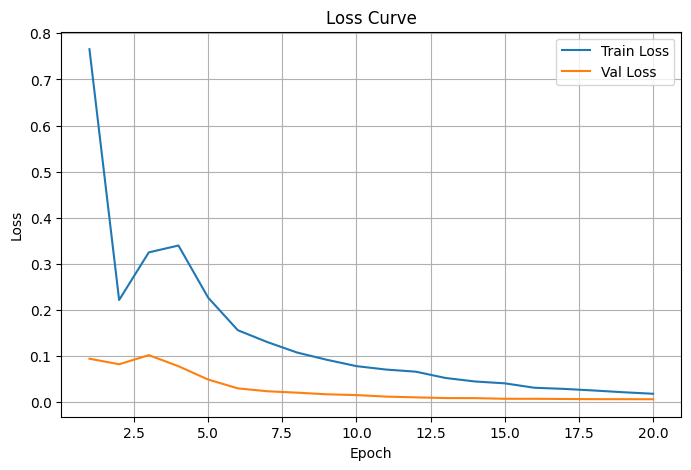

Accuracy columns: ['metrics/accuracy_top1', 'metrics/accuracy_top5']


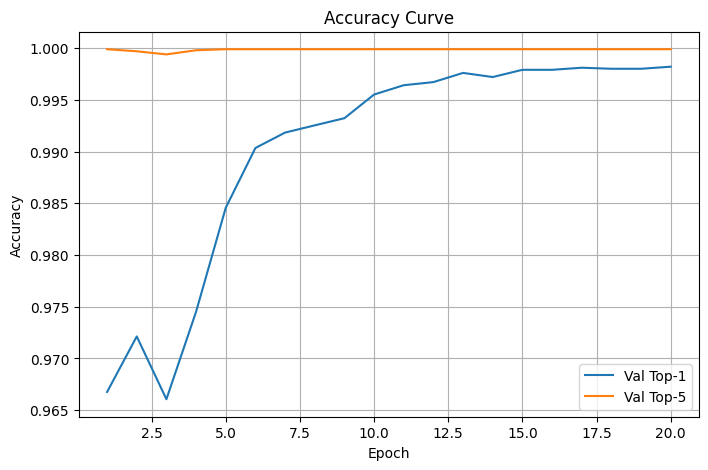

In [ ]:

RESULTS_CSV = PROJECT_DIR / RUN_NAME / "results.csv"
df = pd.read_csv(RESULTS_CSV)

plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train/loss"], label="Train Loss")
plt.plot(df["epoch"], df["val/loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curve"); plt.legend(); plt.grid(); plt.show()

acc_cols = [c for c in df.columns if "acc" in c.lower()]
print("Accuracy columns:", acc_cols)
plt.figure(figsize=(8,5))
if "metrics/accuracy_top1" in df.columns:
    plt.plot(df["epoch"], df["metrics/accuracy_top1"], label="Val Top-1")
if "metrics/accuracy_top5" in df.columns:
    plt.plot(df["epoch"], df["metrics/accuracy_top5"], label="Val Top-5")
if "train/acc" in df.columns:
    plt.plot(df["epoch"], df["train/acc"], "--", label="Train Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy Curve"); plt.legend(); plt.grid(); plt.show()


Total images: 10038
Collected: (10038,) (10038, 29)


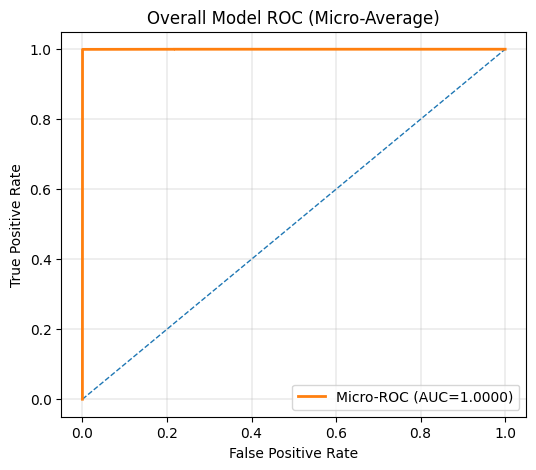

In [ ]:

!pip -q install -U ultralytics scikit-learn pillow

import os, gc, math, numpy as np, matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path as P
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


gc.collect()


CKPT = "/content/drive/MyDrive/YOLO_results/plantvillage_cls_yolo11_lr1e3/weights/best.pt"   # عدّلي لو مختلف
DATA_DIR  = P("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")
SPLIT_DIR = DATA_DIR / ("test" if (DATA_DIR/"test").exists() else "val")


model = YOLO(CKPT)
names = model.names
n_classes = len(names)


VALID = {".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp"}
imgs = [str(p) for p in SPLIT_DIR.rglob("*") if P(p).suffix.lower() in VALID]
assert imgs, f"لا توجد صور في {SPLIT_DIR}"
print("Total images:", len(imgs))


DEVICE = 'cpu'
BATCH  = 16
CHUNK  = 500
IMGZ   = 224


y_true, y_score = [], []
from pathlib import Path as _P
for s in range(0, len(imgs), CHUNK):
    part = imgs[s:s+CHUNK]
    gen = model.predict(part, imgsz=IMGZ, batch=BATCH, device=DEVICE, stream=True, verbose=False)
    for r in gen:
        if r.probs is None:
            continue
        probs = r.probs.data.cpu().numpy()
        cls_id = list(names.values()).index(_P(r.path).parent.name)
        y_true.append(cls_id); y_score.append(probs)
    del gen; gc.collect()

y_true  = np.array(y_true)
y_score = np.array(y_score)
print("Collected:", y_true.shape, y_score.shape)


y_bin = label_binarize(y_true, classes=np.arange(n_classes))
fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), y_score.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

plt.figure(figsize=(6,5))
plt.plot([0,1],[0,1],'--',linewidth=1)
plt.plot(fpr_micro, tpr_micro, linewidth=2, label=f"Micro-ROC (AUC={auc_micro:.4f})")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Overall Model ROC (Micro-Average)")
plt.legend(); plt.grid(True, linewidth=0.3); plt.show()


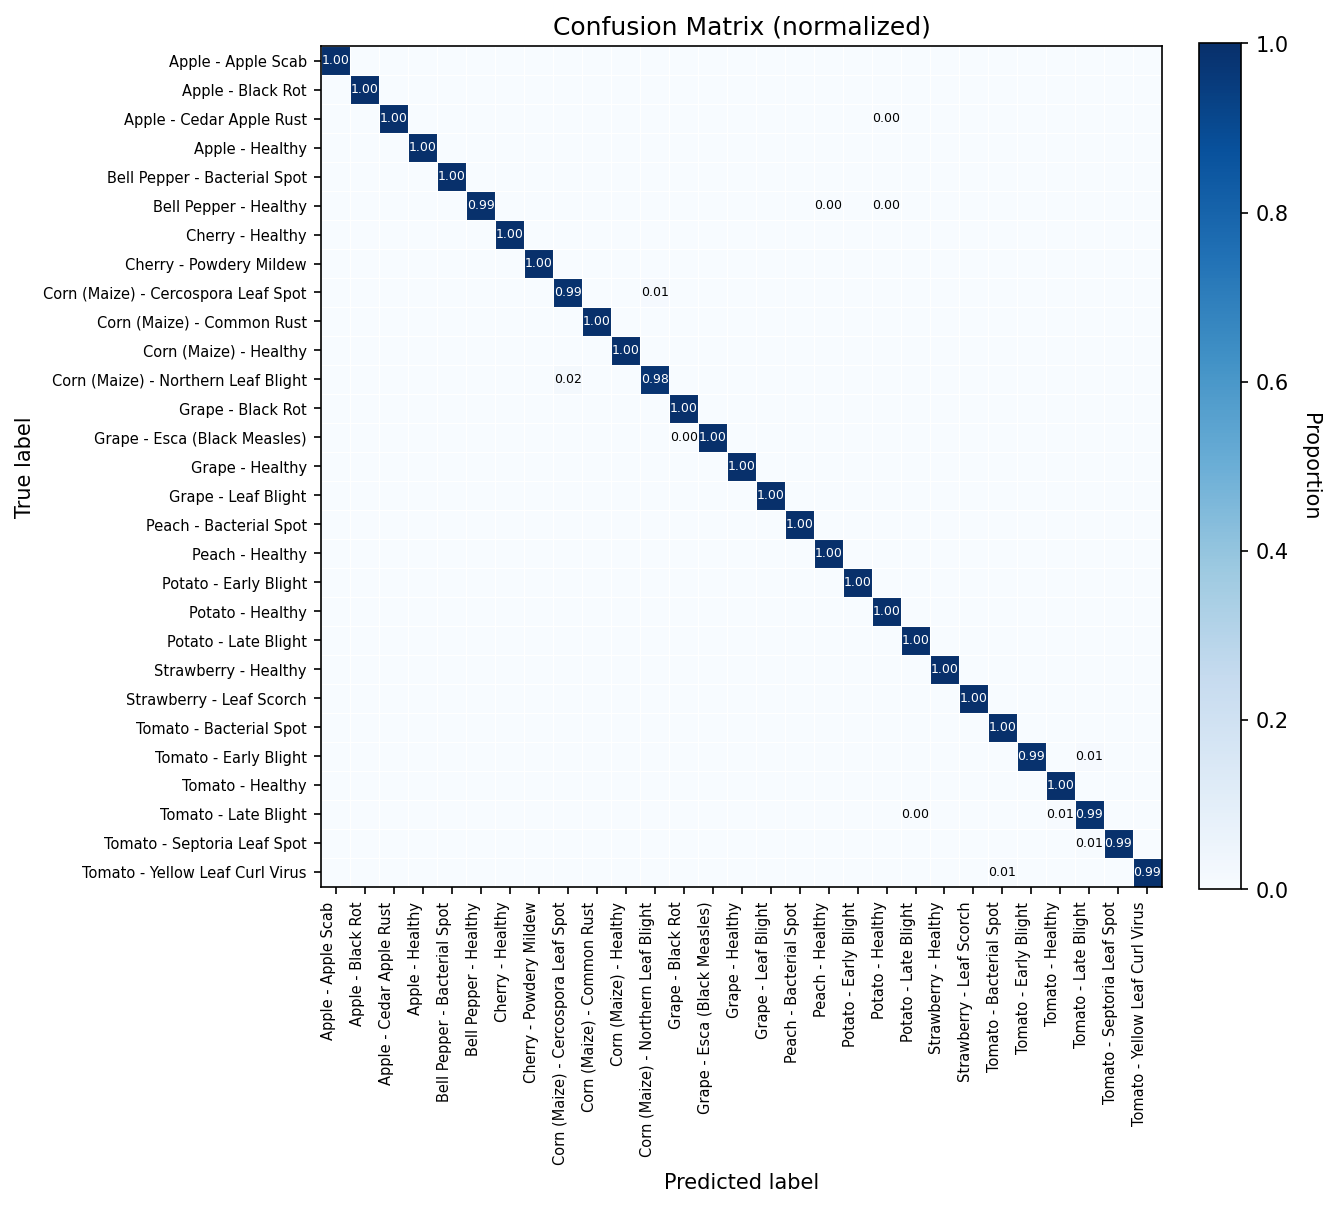

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confmat_pretty(y_true, y_pred, class_names, normalize=True, save_path=None):

    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))


    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)


    fig, ax = plt.subplots(figsize=(9, 9), dpi=150)
    im = ax.imshow(
        cm,
        cmap="Blues",
        vmin=0, vmax=1 if normalize else cm.max(),
        interpolation="nearest"
    )


    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proportion" if normalize else "Count", rotation=270, labelpad=15)


    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix (normalized)" if normalize else "Confusion Matrix")

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90, ha="right", fontsize=7)
    ax.set_yticklabels(class_names, fontsize=7)


    ax.set_xticks(np.arange(-.5, len(class_names), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(class_names), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)


    fmt = ".2f" if normalize else "d"
    thresh = 0.5 if normalize else cm.max()/2
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            v = cm[i, j]
            if v > 0:
                ax.text(j, i, format(v, fmt),
                        ha="center", va="center",
                        color=("white" if v >= thresh else "black"),
                        fontsize=6)

    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()


labels = list(model.names.values())

plot_confmat_pretty(y_true, y_pred, labels, normalize=True)


In [ ]:

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report


precision = precision_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')
f1        = f1_score(y_true, y_pred, average='macro')
acc       = accuracy_score(y_true, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(model.names.values())))


Accuracy  : 0.9976
Precision : 0.9975
Recall    : 0.9976
F1-score  : 0.9976

📋 Classification Report:
                                     precision    recall  f1-score   support

                 Apple - Apple Scab       1.00      1.00      1.00       378
                  Apple - Black Rot       1.00      1.00      1.00       372
           Apple - Cedar Apple Rust       1.00      1.00      1.00       326
                    Apple - Healthy       1.00      1.00      1.00       375
       Bell Pepper - Bacterial Spot       1.00      1.00      1.00       358
              Bell Pepper - Healthy       1.00      0.99      1.00       372
                   Cherry - Healthy       1.00      1.00      1.00       343
            Cherry - Powdery Mildew       1.00      1.00      1.00       315
Corn (Maize) - Cercospora Leaf Spot       0.98      0.99      0.99       308
         Corn (Maize) - Common Rust       1.00      1.00      1.00       357
             Corn (Maize) - Healthy       1.00    

In [ ]:

from google.colab import files
uploaded = files.upload()


Saving TomatoEarlyBlight1.jpg to TomatoEarlyBlight1 (1).jpg


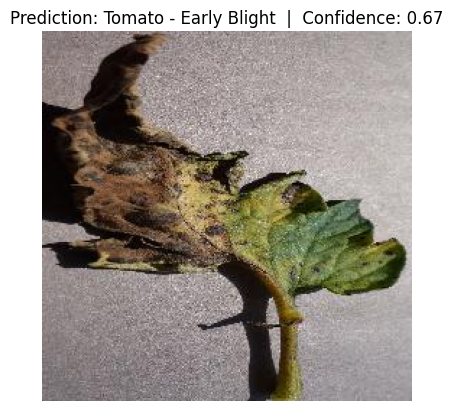

In [ ]:

from PIL import Image
import matplotlib.pyplot as plt


img_path = "TomatoEarlyBlight1.jpg"


result = model.predict(source=img_path, imgsz=224)


plt.imshow(Image.open(img_path))
plt.title(f"Prediction: {result[0].names[result[0].probs.top1]}  |  Confidence: {result[0].probs.top1conf:.2f}")
plt.axis("off")
plt.show()
